## 1. Khởi tạo và Load dữ liệu đã xử lý

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

def load_data_bundle(file_path='./data/processed/processed_data_bundle.joblib'):
    """
    Load toàn bộ tập Train/Test từ file joblib và in ra kích thước kiểm tra.
    """
    if not os.path.exists(file_path):
        print(f"❌ Không tìm thấy file tại: {file_path}")
        return None
    
    # Load bundle
    data = joblib.load(file_path)
    
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']
    
    # Kiểm tra kích thước
    print("--- KIỂM TRA KÍCH THƯỚC DỮ LIỆU ---")
    print(f"Shape X_train: {X_train.shape} | Shape y_train: {y_train.shape}")
    print(f"Shape X_test:  {X_test.shape}  | Shape y_test:  {y_test.shape}")
    
    # Kiểm tra tỷ lệ nợ xấu để đảm bảo Stratified Split hoạt động đúng
    train_default_rate = (y_train.sum() / len(y_train) * 100).round(2)
    test_default_rate = (y_test.sum() / len(y_test) * 100).round(2)
    
    print(f"\n--- TỶ LỆ NỢ XẤU (DEFAULT RATE) ---")
    print(f"Trong tập Train: {train_default_rate}%")
    print(f"Trong tập Test:  {test_default_rate}%")
    
    return X_train, X_test, y_train, y_test

# --- THỰC THI KIỂM TRA ---
# X_train, X_test, y_train, y_test = load_data_bundle()

# Load dữ liệu từ bước trước
X_train, X_test, y_train, y_test = load_data_bundle('./data/processed/processed_data_bundle.joblib')

# Gộp tạm thời X và y để thực hiện EDA dễ dàng hơn
df_eda = X_train.copy()
df_eda['Default'] = y_train

--- KIỂM TRA KÍCH THƯỚC DỮ LIỆU ---
Shape X_train: (204277, 22) | Shape y_train: (204277,)
Shape X_test:  (51070, 22)  | Shape y_test:  (51070,)

--- TỶ LỆ NỢ XẤU (DEFAULT RATE) ---
Trong tập Train: 11.61%
Trong tập Test:  11.61%


In [2]:
df_eda.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,Default
15826,45,37039.0,247916.0,624.0,19,2,4.62,60,0.85,0.0,...,False,False,True,True,False,False,False,False,False,0
147371,48,133963.0,66275.0,494.0,119,3,14.72,48,0.49,3.0,...,False,True,False,True,False,False,False,False,True,0
178180,47,100204.0,6967.0,718.0,108,3,5.51,24,0.76,0.0,...,False,True,False,False,True,True,False,False,False,0
126915,42,36078.0,25966.0,344.0,2,3,18.29,36,0.76,NaN,...,False,True,False,True,False,False,True,False,False,0
163930,20,99464.0,248557.0,318.0,74,3,19.45,60,0.45,NaN,...,True,False,False,False,False,False,False,False,False,1


## 2. Các hàm phân tích Trực quan (EDA Functions)

Các cột còn chứa dữ liệu dạng chuỗi (cần xử lý):
['HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


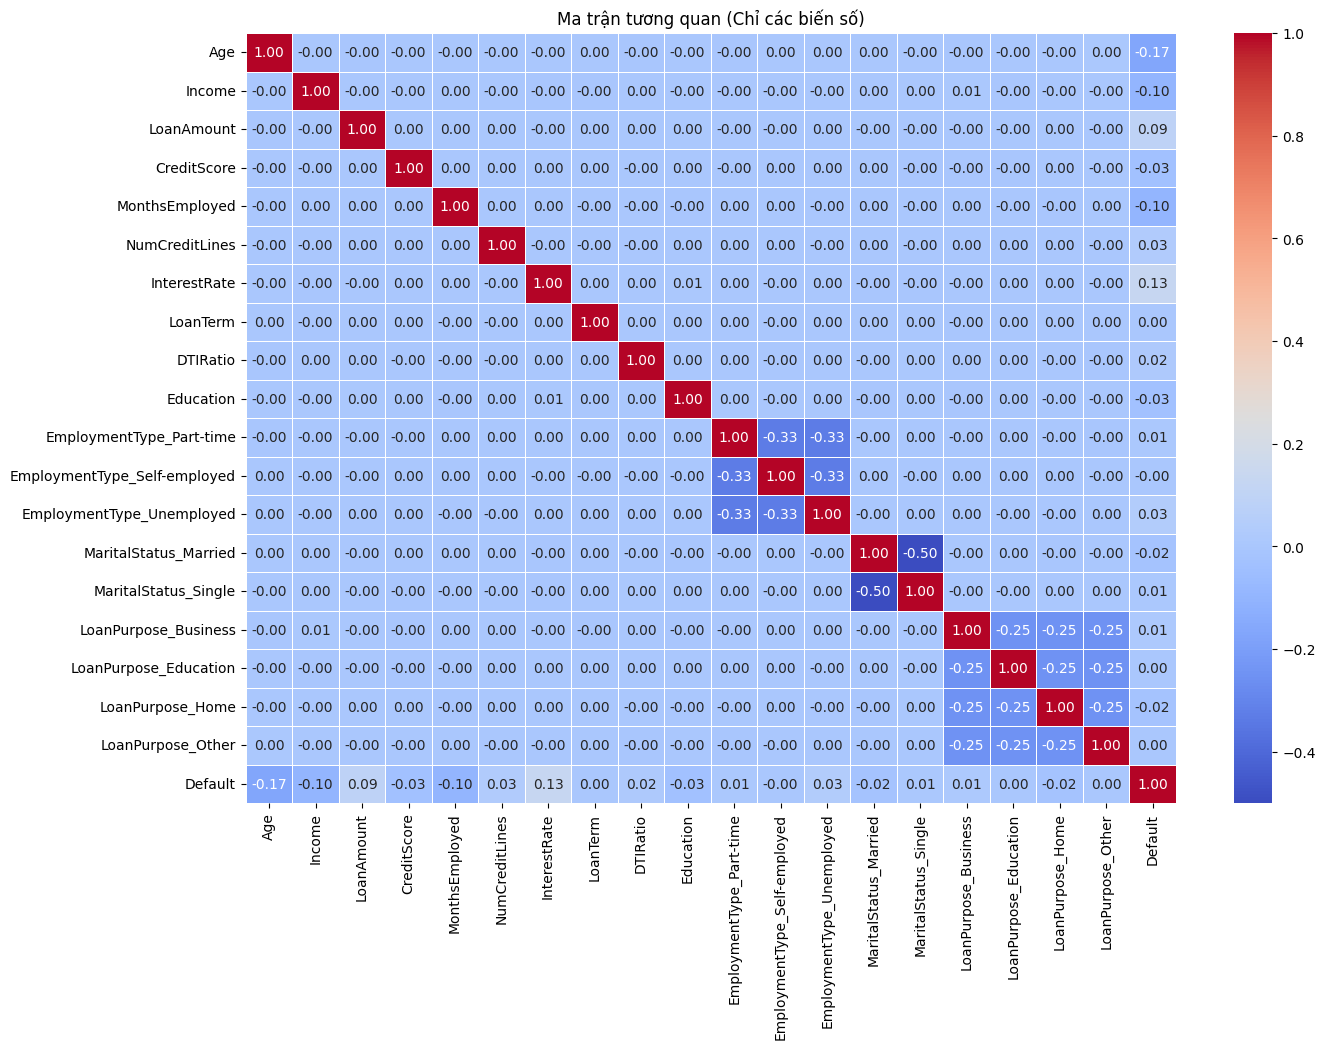

In [3]:
# 2.1. Phân tích Tương quan (Correlation)
def plot_correlation_heatmap(df):
    """Vẽ biểu đồ nhiệt tương quan, chỉ tính toán trên các cột dữ liệu số."""
    plt.figure(figsize=(15, 10))
    
    # CHIẾN THUẬT: Chỉ chọn các cột có kiểu dữ liệu là số (int, float, bool)
    numeric_df = df.select_dtypes(include=[np.number, 'bool'])
    
    # Tính tương quan
    corr = numeric_df.corr()
    
    # Vẽ heatmap
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title("Ma trận tương quan (Chỉ các biến số)")
    plt.show()

# Kiểm tra danh sách các cột không phải là số
print("Các cột còn chứa dữ liệu dạng chuỗi (cần xử lý):")
print(df_eda.select_dtypes(exclude=[np.number]).columns.tolist())

# Thực thi:
plot_correlation_heatmap(df_eda)

C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\340465524.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df[target] == 0], x=feature, label='Trả nợ tốt (0)', shade=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\340465524.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df[target] == 1], x=feature, label='Vỡ nợ (1)', shade=True)


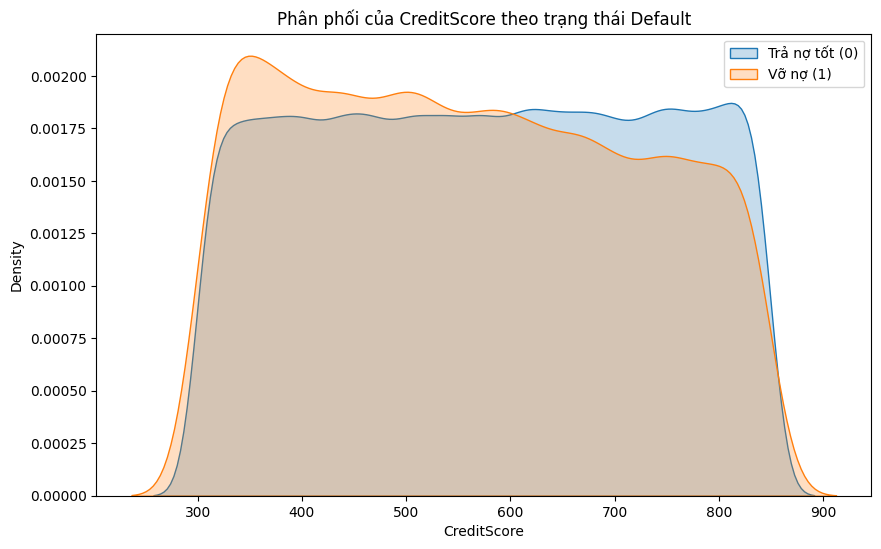

In [4]:
# 2.2. Phân tích Phân phối rủi ro (Risk Distribution)
def plot_risk_distribution(df, feature, target='Default'):
    """So sánh phân phối của một biến số giữa nhóm Default và Non-Default."""
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df[df[target] == 0], x=feature, label='Trả nợ tốt (0)', shade=True)
    sns.kdeplot(data=df[df[target] == 1], x=feature, label='Vỡ nợ (1)', shade=True)
    plt.title(f"Phân phối của {feature} theo trạng thái Default")
    plt.legend()
    plt.show()

# Ví dụ kiểm tra CreditScore:
plot_risk_distribution(df_eda, 'CreditScore')

# 3. Feature Engineering

In [5]:
def create_financial_ratios(df):
    """Tạo các tỷ lệ tài chính cốt lõi."""
    df_new = df.copy()
    
    # 1. Tỷ lệ Khoản vay trên Thu nhập (LTI)
    df_new['LoanToIncomeRatio'] = df_new['LoanAmount'] / (df_new['Income'] + 1)
    
    # 2. Tỷ lệ nợ hàng tháng thực tế (Ước tính từ DTI)
    # Giả định DTI đã có sẵn, ta tạo thêm biến tương tác giữa CreditScore và DTI
    df_new['RiskScore_DTI_Combo'] = df_new['CreditScore'] * (1 - df_new['DTIRatio'])
    
    # 3. Tỷ lệ thâm niên làm việc trên độ tuổi
    df_new['WorkLifeRatio'] = df_new['MonthsEmployed'] / (df_new['Age'] * 12)
    
    print("✅ Đã tạo thêm các biến Ratio mới.")
    return df_new

def apply_feature_selection(df, threshold=0.9):
    """Loại bỏ các biến bị trùng lặp thông tin (Multicollinearity)."""
    corr_matrix = df.drop(columns=['Default'], errors='ignore').corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    df_reduced = df.drop(columns=to_drop)
    
    print(f"✅ Đã loại bỏ {len(to_drop)} biến có tương quan quá cao: {to_drop}")
    return df_reduced

# Main Flow

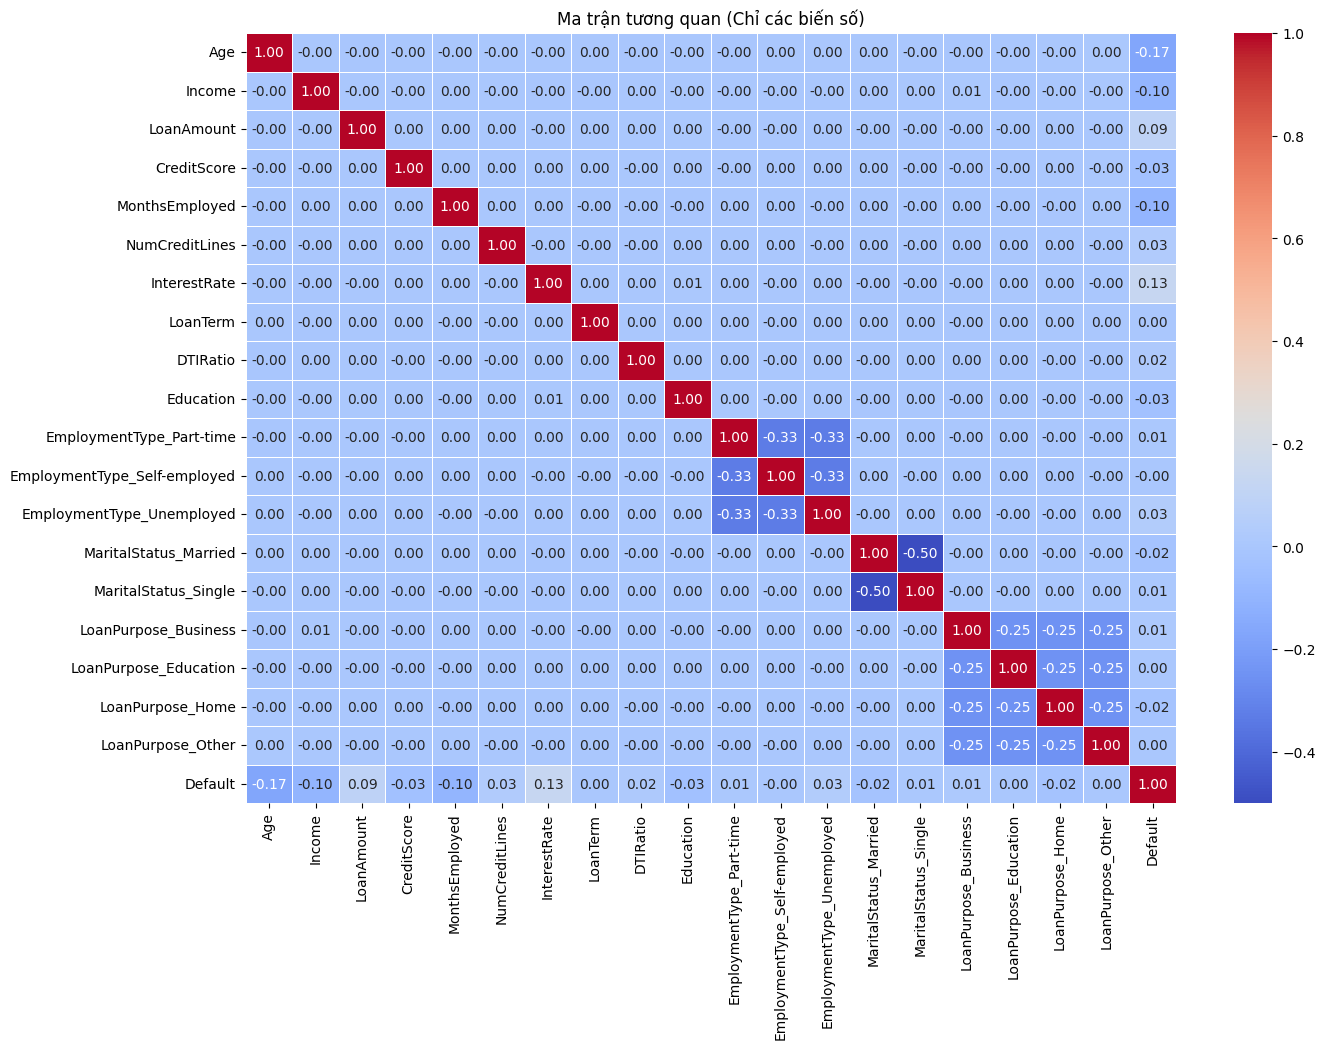

C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\340465524.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df[target] == 0], x=feature, label='Trả nợ tốt (0)', shade=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\340465524.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df[target] == 1], x=feature, label='Vỡ nợ (1)', shade=True)


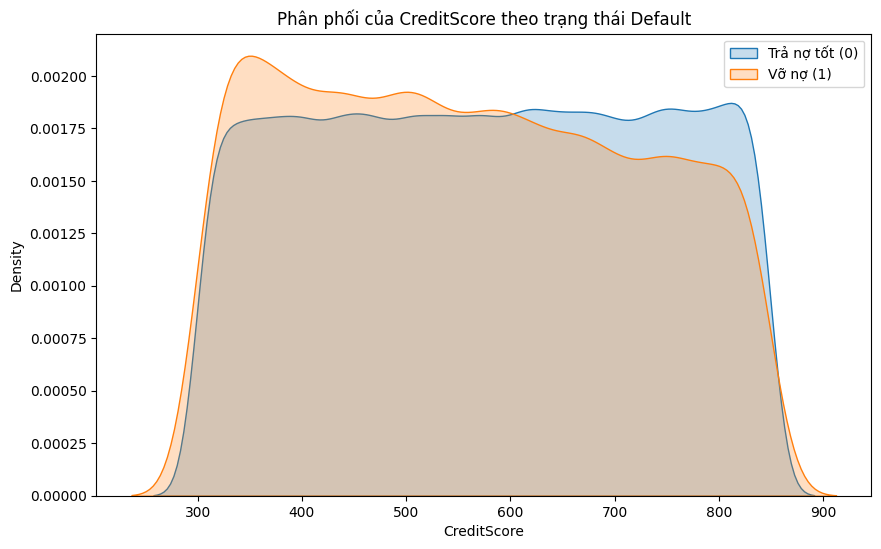

C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\340465524.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df[target] == 0], x=feature, label='Trả nợ tốt (0)', shade=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\340465524.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df[target] == 1], x=feature, label='Vỡ nợ (1)', shade=True)


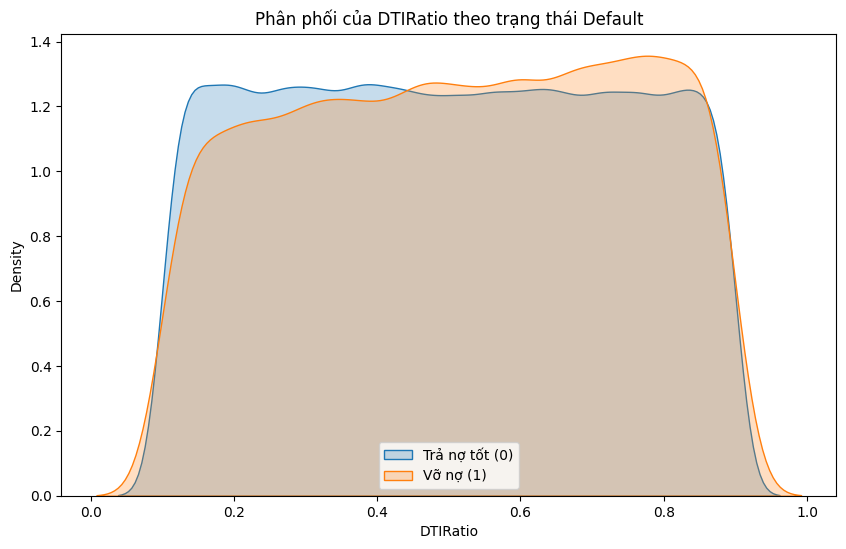

C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\340465524.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df[target] == 0], x=feature, label='Trả nợ tốt (0)', shade=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\340465524.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df[target] == 1], x=feature, label='Vỡ nợ (1)', shade=True)


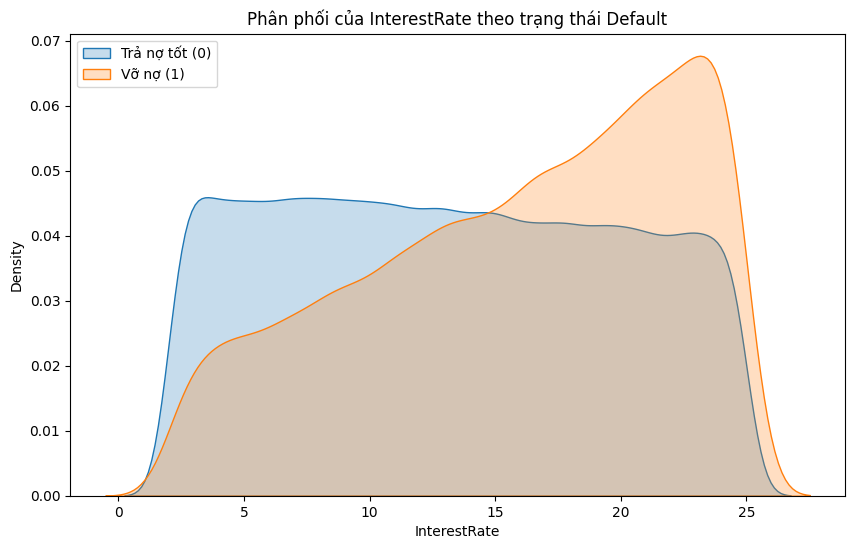

✅ Đã tạo thêm các biến Ratio mới.
✅ Đã tạo thêm các biến Ratio mới.

🚀 HOÀN TẤT EDA & FEATURE ENGINEERING. DỮ LIỆU ĐÃ SẴN SÀNG CHO MODELING!


In [6]:
# --- STEP 1: EDA ---
plot_correlation_heatmap(df_eda)
# Kiểm tra các biến 'vàng'
for col in ['CreditScore', 'DTIRatio', 'InterestRate']:
    plot_risk_distribution(df_eda, col)

# --- STEP 2: FEATURE ENGINEERING ---
# Áp dụng tạo biến cho cả tập Train và Test (để đồng bộ)
X_train_ext = create_financial_ratios(X_train)
X_test_ext = create_financial_ratios(X_test)

# --- STEP 3: LỌC BIẾN & LƯU TRỮ ---
# Lưu lại bộ dữ liệu cuối cùng (Final Features) để chuẩn bị cho Modeling
final_bundle = {
    'X_train': X_train_ext, 'X_test': X_test_ext,
    'y_train': y_train, 'y_test': y_test
}
joblib.dump(final_bundle, './data/processed/final_feature_bundle.joblib')

print("\n🚀 HOÀN TẤT EDA & FEATURE ENGINEERING. DỮ LIỆU ĐÃ SẴN SÀNG CHO MODELING!")

In [7]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

def prepare_final_features(X_train_raw, X_test_raw, y_train, y_test, file_path='./data/processed/final_feature_bundle.joblib'):
    """
    Xử lý triệt để NaN, Encoding và Scaling tại nguồn.
    Đảm bảo Train và Test đồng bộ 100% về số lượng và tên cột.
    """
    
    def process_df(df):
        df_proc = df.copy()
        
        # 1. Chuyển đổi Binary 'Yes'/'No' sang 1/0 và đặt tên chuẩn _Yes
        binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
        for col in binary_cols:
            if col in df_proc.columns:
                df_proc[f"{col}_Yes"] = df_proc[col].map({'Yes': 1, 'No': 0, 1: 1, 0: 0})
                df_proc = df_proc.drop(columns=[col])

        # 2. Điền giá trị thiếu (NaN)
        num_cols = df_proc.select_dtypes(include=[np.number]).columns
        df_proc[num_cols] = df_proc[num_cols].fillna(df_proc[num_cols].median())
        
        # 3. One-Hot Encoding cho các biến phân loại (Education, EmploymentType, MaritalStatus, LoanPurpose)
        cat_cols = df_proc.select_dtypes(include=['object']).columns.tolist()
        if cat_cols:
            df_proc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True)
            
        return df_proc

    # --- Thực thi xử lý ---
    X_train_final = process_df(X_train_raw)
    X_test_final = process_df(X_test_raw)

    # 4. Đảm bảo tập Test khớp cột với tập Train (Xử lý lỗi feature mismatch)
    X_test_final = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)

    # 5. Scaling (Bắt buộc cho Logistic Regression, không hại gì cho RF/XGBoost)
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=X_train_final.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns)

    # 6. Đóng gói và Lưu trữ
    final_bundle = {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test
    }
    
    joblib.dump(final_bundle, file_path)
    print(f"✅ Đã tạo bộ dữ liệu FINAL thành công!")
    print(f"📊 Số lượng đặc trưng: {X_train_scaled.shape[1]}")
    print(f"📋 Danh sách cột: {X_train_scaled.columns.tolist()}")
    
    return final_bundle

# --- CÁCH GỌI ---
bundle = prepare_final_features(X_train, X_test, y_train, y_test)

✅ Đã tạo bộ dữ liệu FINAL thành công!
📊 Số lượng đặc trưng: 22
📋 Danh sách cột: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'HasMortgage_Yes', 'HasDependents_Yes', 'HasCoSigner_Yes']
